# Financial News Exploratory Data Analysis

## 10 Academy Week 1 Challenge

### Objective

This notebook performs exploratory data analysis (EDA) on a financial news dataset.

The goal is to understand the structure, patterns, trends, and statistical properties of the data before performing sentiment analysis and stock market correlation analysis.

---

## Analysis Overview

This notebook includes:

- Dataset overview
- Missing value analysis
- Descriptive statistics
- Headline length analysis
- Publisher analysis
- Publication date analysis
- Time-series analysis of news volume
- Publishing hour analysis
- NLP keyword extraction
- TF-IDF analysis
- Bigram phrase analysis
- Publisher domain analysis
- Visualizations and insights

In [66]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text processing
import re

# NLP
from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfVectorizer
)

# Display settings
pd.set_option('display.max_columns', None)

# Plot style
plt.style.use('ggplot')

# Load Dataset

The dataset contains:

- Financial news headlines
- Publishers
- Publication dates
- Stock symbols
- URLs

In [67]:
# Load dataset

df = pd.read_csv('../data/raw/raw_analyst_ratings.csv')

# Preview dataset

df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


# Dataset Overview

This section explores:

- Dataset dimensions
- Column names
- Data types
- Initial structure

In [68]:
# Dataset shape

print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(1407328, 6)


In [69]:
# Column names

print("Columns:")
print(df.columns)

Columns:
Index(['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock'], dtype='str')


In [70]:
# Dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   Unnamed: 0  1407328 non-null  int64
 1   headline    1407328 non-null  str  
 2   url         1407328 non-null  str  
 3   publisher   1407328 non-null  str  
 4   date        1407328 non-null  str  
 5   stock       1407328 non-null  str  
dtypes: int64(1), str(5)
memory usage: 64.4 MB


# Missing Value Analysis

This section checks for missing or null values across all columns.

In [71]:
# Missing values

missing_values = df.isnull().sum()

missing_values

Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64

## Observation

The dataset contains minimal missing values.

Most critical columns such as headlines, publishers, and dates are populated and suitable for analysis.

# Descriptive Statistics

This section analyzes:

- Headline lengths
- Distribution of textual sizes
- General statistical properties

In [72]:
# Create headline length column

df['headline_length'] = (
    df['headline']
    .astype(str)
    .apply(len)
)

# Summary statistics

df['headline_length'].describe()

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

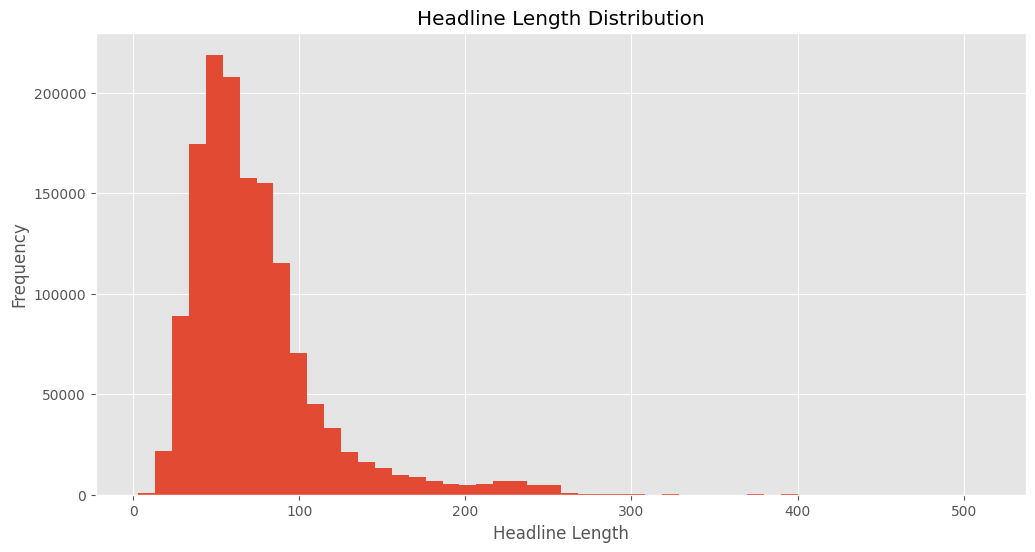

In [73]:
# Headline length distribution

plt.figure(figsize=(12,6))

plt.hist(
    df['headline_length'],
    bins=50
)

plt.title('Headline Length Distribution')

plt.xlabel('Headline Length')

plt.ylabel('Frequency')

plt.show()

## Observation

Most headlines are relatively short and concise.

A smaller number of headlines are significantly longer, which may indicate detailed financial announcements or extended reporting.

# Publisher Analysis

This section identifies:

- Most active publishers
- Publisher contribution patterns
- News distribution across organizations

In [74]:
# Publisher article counts

publisher_counts = (
    df['publisher']
    .value_counts()
)

publisher_counts.head(10)

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

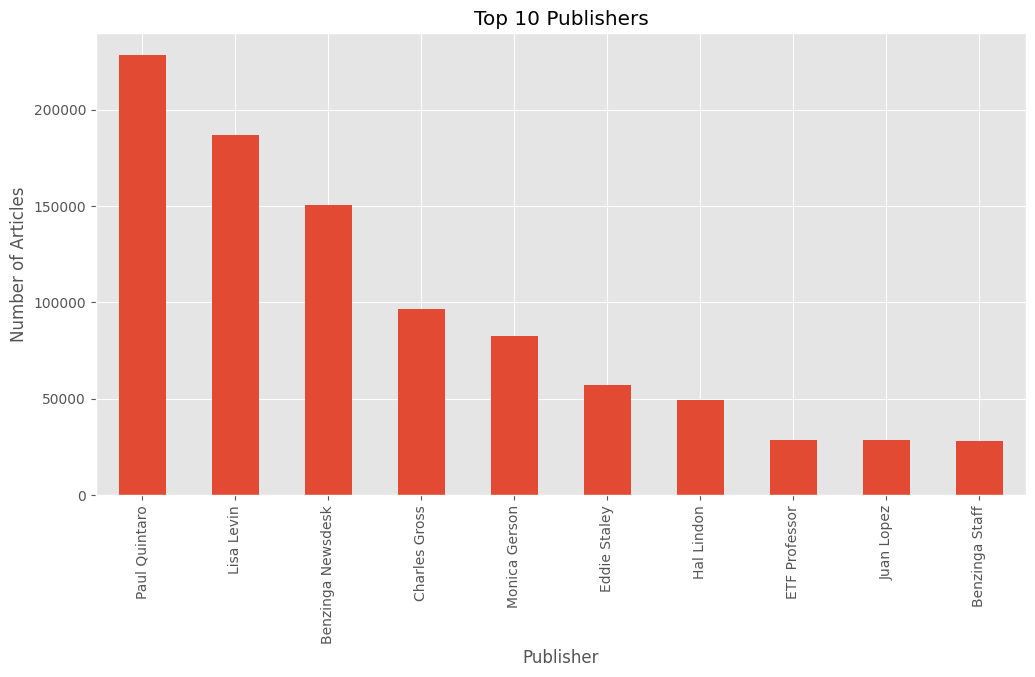

In [75]:
# Top publishers visualization

plt.figure(figsize=(12,6))

publisher_counts.head(10).plot(
    kind='bar'
)

plt.title('Top 10 Publishers')

plt.xlabel('Publisher')

plt.ylabel('Number of Articles')

plt.show()

## Observation

A small number of publishers contribute a large proportion of the financial news articles.

Major financial media organizations dominate the dataset, while smaller publishers contribute more specialized or niche content.

# Publication Date Analysis

This section investigates publication trends over time.

The objective is to identify:

- Variations in news volume
- Periods of unusually high activity
- Possible relationships with major market events

In [76]:
# Convert date column to datetime

df['date'] = pd.to_datetime(
    df['date'],
    errors='coerce'
)

In [77]:
# Daily news volume

daily_news = (
    df.groupby(df['date'].dt.date)
    .size()
)

daily_news.head()

date
2011-04-27    1
2011-04-28    2
2011-04-29    2
2011-04-30    1
2011-05-01    1
dtype: int64

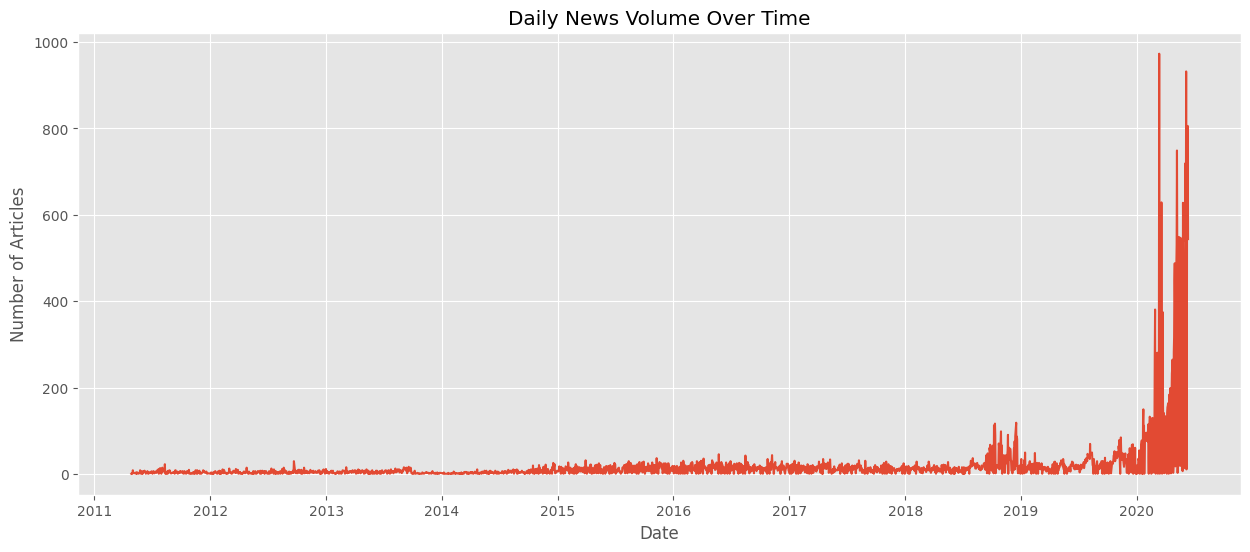

In [78]:
# Daily news volume visualization

plt.figure(figsize=(15,6))

plt.plot(daily_news)

plt.title('Daily News Volume Over Time')

plt.xlabel('Date')

plt.ylabel('Number of Articles')

plt.show()

## Observation

The dataset shows clear spikes in publication activity during certain periods.

These spikes may correspond to:

- Earnings seasons
- Major company announcements
- Economic uncertainty
- High market volatility
- Significant financial events

Periods with unusually high news activity are likely associated with increased investor attention and market reactions.

# Publishing Time Analysis

This section analyzes the time of day when articles are published.

In [79]:
# Extract publishing hour

df['hour'] = df['date'].dt.hour

df['hour'].head()

0    10.0
1    10.0
2     4.0
3    12.0
4    11.0
Name: hour, dtype: float64

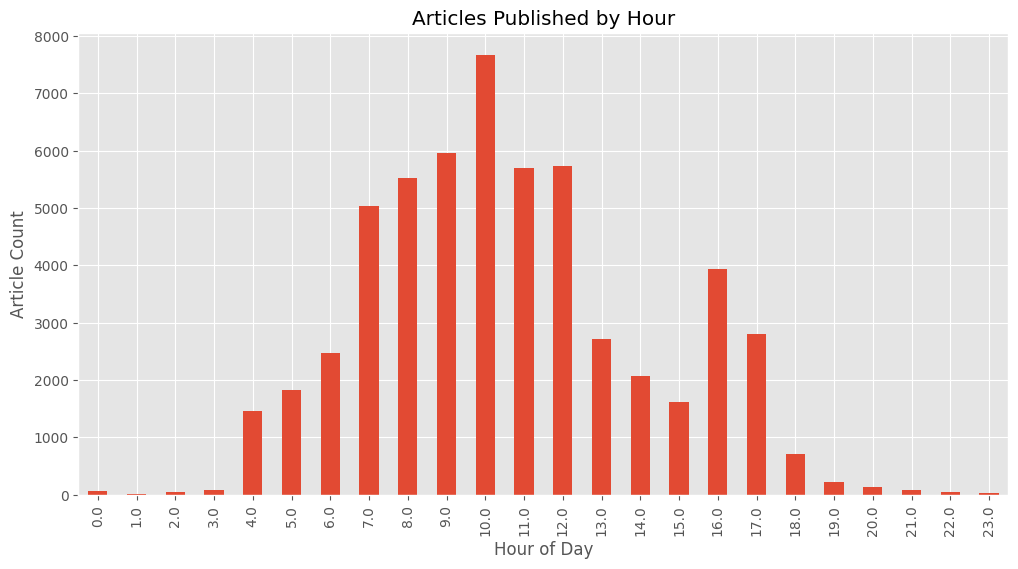

In [80]:
# Publishing hour distribution

plt.figure(figsize=(12,6))

(
    df['hour']
    .value_counts()
    .sort_index()
    .plot(kind='bar')
)

plt.title('Articles Published by Hour')

plt.xlabel('Hour of Day')

plt.ylabel('Article Count')

plt.show()

## Observation

Most financial news articles are published during standard business and trading hours.

This suggests strong alignment between news publication activity and financial market operations.

# Text Cleaning

Before performing NLP analysis, headlines are cleaned by:

- converting text to lowercase
- removing punctuation
- removing special characters

In [94]:
def clean_text(text):
    
    # Convert to lowercase
    text = str(text).lower()
    
    # Replace non-letters with spaces
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    
    # Remove extra spaces
    text = re.sub(r'\\s+', ' ', text).strip()
    
    return text

# Apply cleaning

df['clean_headline'] = (
    df['headline']
    .apply(clean_text)
)

df[['headline', 'clean_headline']].head(10)

,headline,clean_headline
0,Stocks That Hit 52-Week Highs On Friday,stocks that hit week highs on friday
1,Stocks That Hit 52-Week Highs On Wednesday,stocks that hit week highs on wednesday
2,71 Biggest Movers From Friday,biggest movers from friday
3,46 Stocks Moving In Friday's Mid-Day Session,stocks moving in friday s mid day session
4,"B of A Securities Maintains Neutral on Agilent Technologies, Raises Price Target to $88",b of a securities maintains neutral on agilent technologies raises price target to
5,"CFRA Maintains Hold on Agilent Technologies, Lowers Price Target to $85",cfra maintains hold on agilent technologies lowers price target to
6,"UBS Maintains Neutral on Agilent Technologies, Raises Price Target to $87",ubs maintains neutral on agilent technologies raises price target to
7,Agilent Technologies shares are trading higher after the company reported better-than-expected Q2 EPS and sales results.,agilent technologies shares are trading higher after the company reported better than expected q eps and sales results
8,"Wells Fargo Maintains Overweight on Agilent Technologies, Raises Price Target to $95",wells fargo maintains overweight on agilent technologies raises price target to
9,10 Biggest Price Target Changes For Friday,biggest price target changes for friday


# Keyword Frequency Analysis

This section identifies the most common words appearing in financial headlines using CountVectorizer.

In [82]:
# CountVectorizer

vectorizer = CountVectorizer(
    stop_words='english',
    max_features=20
)

X = vectorizer.fit_transform(
    df['clean_headline']
)

words = vectorizer.get_feature_names_out()

counts = X.toarray().sum(axis=0)

In [83]:
# Word frequency dataframe

word_df = pd.DataFrame({
    'word': words,
    'count': counts
})

word_df = word_df.sort_values(
    by='count',
    ascending=False
)

word_df

,word,count
18,vs,162126
15,stocks,161776
6,est,140650
5,eps,128917
7,market,120560
14,shares,114315
12,reports,108711
17,update,91723
4,earnings,87399
13,sales,79648


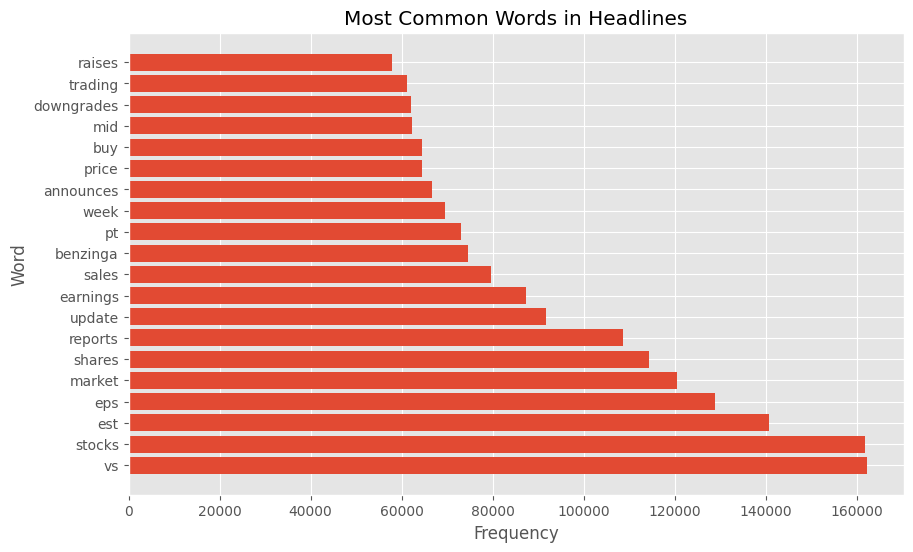

In [84]:
# Most common words visualization

plt.figure(figsize=(10,6))

plt.barh(
    word_df['word'],
    word_df['count']
)

plt.title('Most Common Words in Headlines')

plt.xlabel('Frequency')

plt.ylabel('Word')

plt.show()

## Observation

Frequently occurring words include:

- stock
- earnings
- market
- shares
- price

These keywords indicate that the dataset strongly focuses on financial performance, stock movement, and market analysis.

# TF-IDF Analysis

TF-IDF (Term Frequency–Inverse Document Frequency) identifies words that are not only frequent but also important and distinctive within the dataset.

In [85]:
# TF-IDF Vectorizer

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=20
)

tfidf_matrix = tfidf.fit_transform(
    df['clean_headline']
)

tfidf_words = tfidf.get_feature_names_out()

tfidf_scores = tfidf_matrix.sum(axis=0).A1

In [86]:
# TF-IDF dataframe

tfidf_df = pd.DataFrame({
    'word': tfidf_words,
    'score': tfidf_scores
})

tfidf_df = tfidf_df.sort_values(
    by='score',
    ascending=False
)

tfidf_df

,word,score
15,stocks,120048.528450
7,market,83039.168563
14,shares,77561.328530
4,earnings,75180.532288
18,vs,65473.114764
12,reports,64124.973185
17,update,63627.140840
1,benzinga,62142.520528
5,eps,61192.385984
0,announces,55963.661954


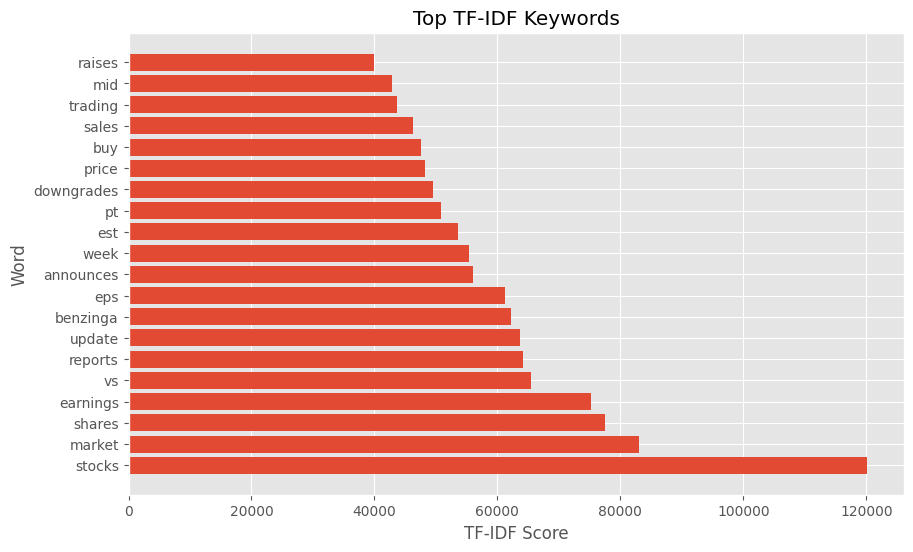

In [87]:
# TF-IDF visualization

plt.figure(figsize=(10,6))

plt.barh(
    tfidf_df['word'],
    tfidf_df['score']
)

plt.title('Top TF-IDF Keywords')

plt.xlabel('TF-IDF Score')

plt.ylabel('Word')

plt.show()

## Observation

TF-IDF highlights words that are particularly important within financial news reporting.

These terms capture the dominant themes and unique financial terminology appearing across the dataset.

# Bigram Phrase Analysis

This section identifies common two-word phrases in headlines.

Bigram analysis helps uncover recurring financial themes such as:

- price target
- earnings beat
- FDA approval
- quarterly results

In [88]:
# Bigram analysis

bigram_vectorizer = CountVectorizer(
    stop_words='english',
    ngram_range=(2,2),
    max_features=20
)

bigram_matrix = bigram_vectorizer.fit_transform(
    df['clean_headline']
)

bigram_words = (
    bigram_vectorizer
    .get_feature_names_out()
)

bigram_counts = (
    bigram_matrix
    .sum(axis=0)
    .A1
)

In [89]:
# Bigram dataframe

bigram_df = pd.DataFrame({
    'bigram': bigram_words,
    'count': bigram_counts
})

bigram_df = bigram_df.sort_values(
    by='count',
    ascending=False
)

bigram_df

,bigram,count
19,vs est,129413
4,eps vs,70271
13,reports eps,51226
11,price target,47274
16,stocks moving,40044
9,mid day,37324
8,market update,33101
3,earnings scheduled,32055
14,sales vs,30452
6,initiates coverage,28993


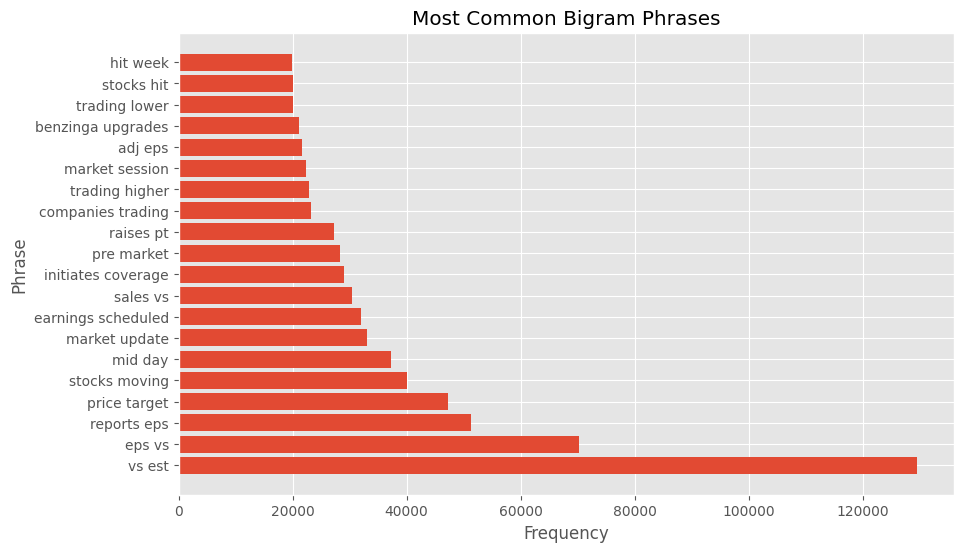

In [90]:
# Bigram visualization

plt.figure(figsize=(10,6))

plt.barh(
    bigram_df['bigram'],
    bigram_df['count']
)

plt.title('Most Common Bigram Phrases')

plt.xlabel('Frequency')

plt.ylabel('Phrase')

plt.show()

## Observation

Bigram analysis reveals recurring financial phrases commonly used in market reporting.

Examples include:

- price target
- earnings report
- analyst rating
- quarterly earnings

These phrases provide stronger contextual understanding than single-word analysis alone.

# Publisher Domain Analysis

Some publisher entries contain email addresses.

This section extracts domains to analyze organizational contribution patterns.

In [91]:
# Extract publisher domains

df['domain'] = (
    df['publisher']
    .astype(str)
    .str.extract(r'@(.+)')
)

df['domain'].value_counts().head(10)

domain
benzinga.com              7937
gmail.com                  139
andyswan.com                 5
investdiva.com               2
tothetick.com                2
eosdetroit.io                1
forextraininggroup.com       1
stockmetrix.net              1
Name: count, dtype: int64

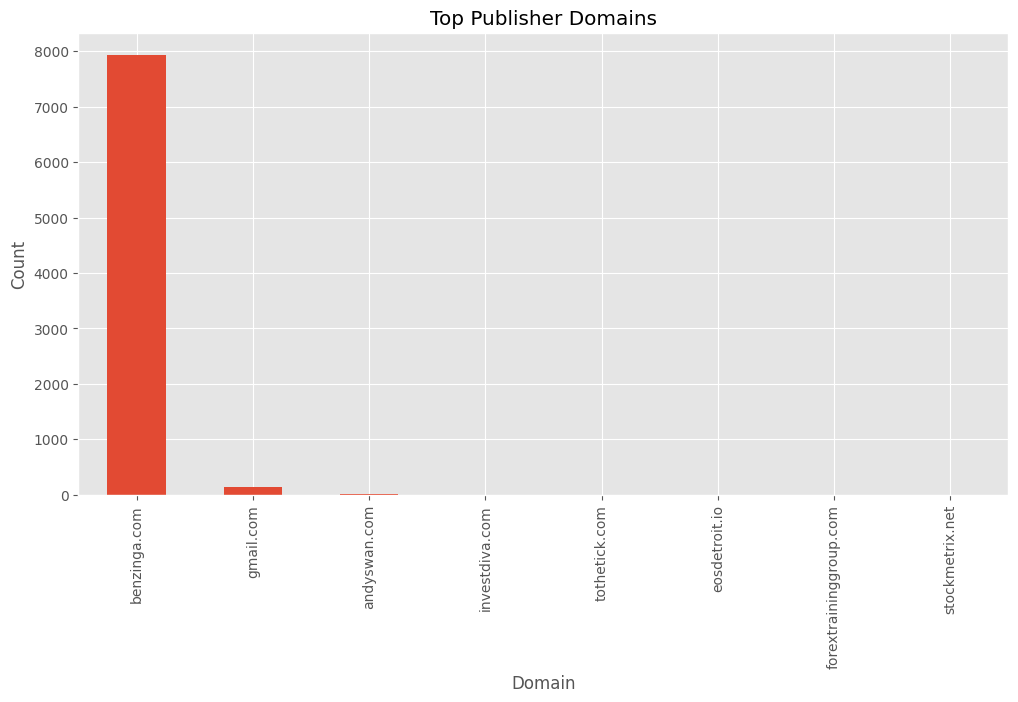

In [92]:
# Publisher domain visualization

plt.figure(figsize=(12,6))

(
    df['domain']
    .value_counts()
    .head(10)
    .plot(kind='bar')
)

plt.title('Top Publisher Domains')

plt.xlabel('Domain')

plt.ylabel('Count')

plt.show()

## Observation

Domain analysis helps identify organizations contributing financial news content.

Some domains represent major financial media organizations, while others correspond to specialized financial newsletters or market analysis services.

# Final Conclusion

This exploratory data analysis produced several important findings:

- Financial headlines are generally concise.
- A small number of publishers dominate article production.
- News publication volume fluctuates significantly over time.
- Publishing activity is concentrated during business hours.
- Financial headlines contain recurring market-related themes and terminology.
- Bigram phrase analysis reveals important contextual financial expressions.

These findings establish a strong foundation for:

- sentiment analysis
- technical analysis
- stock return correlation analysis

in the next stages of the project.